# 04 — Trajetórias, e a faixa estreita muda o vencedor?

Duas perguntas:

1. **Como cada controlador se comporta ao longo do dia**, cenário a cenário? Quem
   de fato mantém a temperatura na faixa, e por qual mecanismo?
2. **Estreitar a faixa alvo favorece o RL?** A intuição é que, quanto mais
   exigente a especificação, mais o aprendizado compensaria.

A segunda é testada com retreinamento, não com re-medição: cobrar ±0,5 °C de um
agente treinado para ±2,0 °C mediria descasamento de objetivo, não capacidade.

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, '/home/renan/Downloads/air_conditioning_classroom/v5')
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hvac import results as R
from hvac import figures as F

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
F.aplicar_estilo()

## 4.1 O dia inteiro, cenário a cenário

Pequenos múltiplos: a comparação que interessa é entre controladores **dentro**
de cada cenário. A faixa alvo aparece sombreada como referência visual comum.

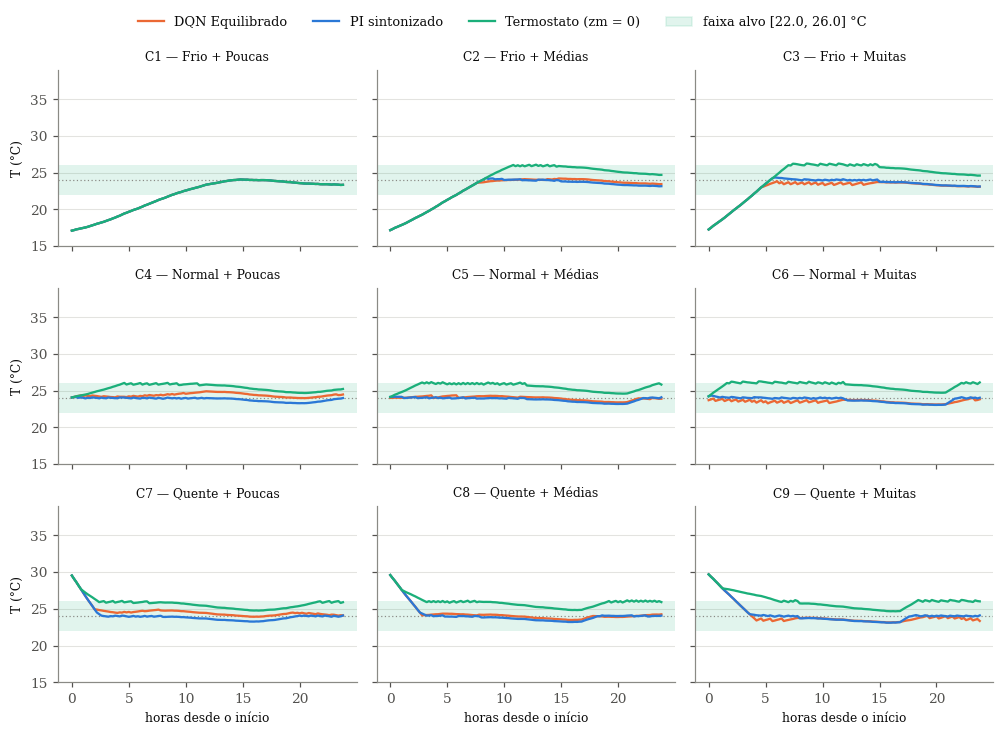

In [2]:
tr = R.trajetorias()
fig = F.fig_trajetorias_grade(tr)
plt.close(fig)
fig

### Leitura

O padrão é imediato e consistente nos oito cenários controláveis: **o termostato
estaciona acima da faixa**, encostado no teto de 26 °C, enquanto PI e DQN ficam
quase sobrepostos em torno de 24 °C.

C1 (Frio + Poucas) é o cenário em que as três curvas coincidem — é exatamente o
excluído pelo filtro de controlabilidade: sem ninguém na sala e partindo de
17 °C, a temperatura sobe sozinha até a faixa e resfriar seria contraprodutivo.
Nenhum controlador se distingue ali, e por isso ele não entra nas médias.

## 4.2 Um dia em detalhe — o mecanismo

A trajetória mostra **quanto** cada um acerta; a ação mostra **como**.

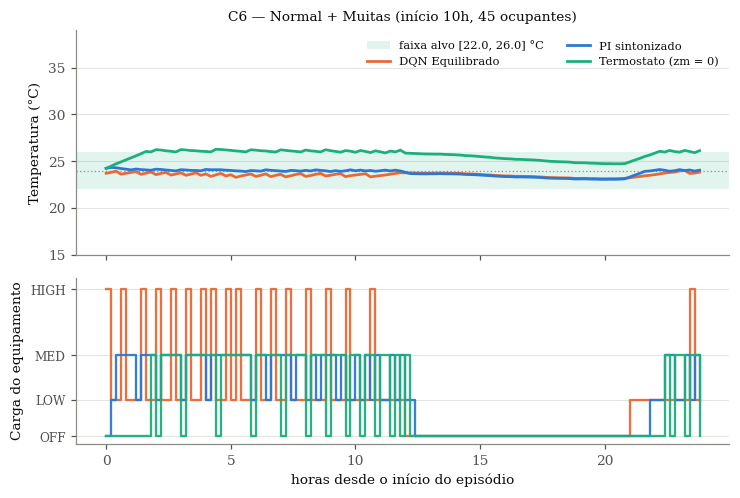

In [3]:
fig = F.fig_trajetoria_detalhe(tr, "C6")
plt.close(fig)
fig

### Leitura

O painel inferior explica o superior. O **termostato** liga em MEDIUM ao cruzar
26 °C e desliga ao voltar — daí o dente-de-serra permanentemente acima da faixa.

O **DQN** comuta entre OFF e HIGH de forma agressiva, com pulsos curtos e
repetidos: é o *short-cycling* visível, o mesmo fenômeno que a distribuição de
permanência quantifica (mediana de 12 min contra requisito de 36).

O **PI** modula: usa LOW e MEDIUM de forma sustentada e recorre a HIGH raramente.
Mesmo resultado de temperatura, mecanismo mais suave — e, como a Seção 4.6
mostra, mais barato.

## 4.3 Apertando a régua, sem retreinar

Primeiro a versão barata da pergunta: mantendo os mesmos controladores, o que
acontece quando se exige mais precisão? Aqui o DQN está em desvantagem
declarada — foi treinado para ±2,0 °C.

In [4]:
sens = R.sensibilidade_a_largura()
sens.pivot(index="tolerancia", columns="controlador",
           values="na_tolerancia_pct").round(1)

controlador,DQN Equilibrado,PI sintonizado,Termostato (zm = 0),Termostato (zm = 1 °C)
tolerancia,,,,
0.25,34.0,73.2,1.7,3.2
0.50,64.2,78.5,3.7,7.8
0.75,80.2,82.0,6.7,11.8
1.00,83.8,83.8,12.2,20.5
1.50,85.3,85.3,20.8,49.2
2.00,86.5,86.5,54.0,77.7


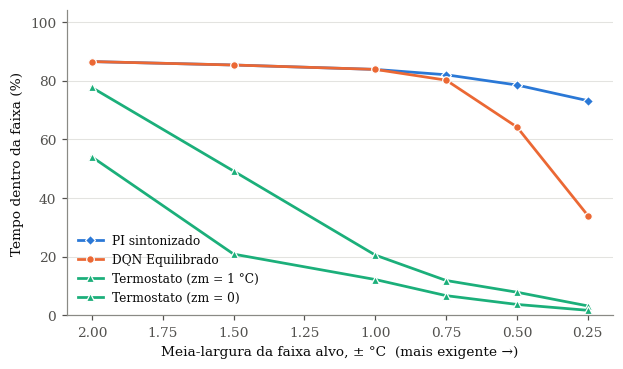

In [5]:
fig = F.fig_sensibilidade_largura(sens)
plt.close(fig)
fig

### Leitura

Em ±2,0 °C, PI e DQN empatam em 86,5 %. À medida que a régua aperta, eles **se
separam**, e a distância cresce monotonicamente: em ±0,25 °C o PI mantém 73,2 %
contra 34,0 % do DQN — mais que o dobro.

Os termostatos colapsam bem antes: de 54,0 % para 1,7 % o de zona morta nula.
Isso confirma que a métrica de faixa larga do manuscrito estava saturada e
escondia a diferença real entre as estratégias.

Mas este teste é injusto com o DQN, e por isso não conclui nada sozinho.

## 4.4 O teste justo: ambos preparados para a faixa

Para cada largura, **dois** controladores são preparados para *aquela* largura:
o DQN é retreinado com a faixa de conforto correspondente, e o PI é
**re-sintonizado** por busca em grade.

Re-sintonizar o PI é a parte não negociável. Congelar os ganhos de ±2,0 °C e
cobrar precisão de ±0,5 °C reproduziria, dentro deste experimento, o mesmo
defeito que a auditoria acusa no manuscrito: vencer um adversário mal
configurado.

In [6]:
fx = R.faixa_estreita()
fx.groupby(["tolerancia", "controlador"])["na_tolerancia_pct"].agg(
    ["mean", "std", "min", "max"]).round(2)

mean   std    min    max
tolerancia controlador                                    
0.5        DQN                   71.50  4.04  69.17  76.17
           PI sintonizado        79.83   NaN  79.83  79.83
           Termostato (zm=1 °C)  63.17   NaN  63.17  63.17
1.0        DQN                   80.83  5.20  74.83  83.83
           PI sintonizado        83.83   NaN  83.83  83.83
           Termostato (zm=1 °C)  72.50   NaN  72.50  72.50
2.0        DQN                   86.50  0.00  86.50  86.50
           PI sintonizado        86.50   NaN  86.50  86.50
           Termostato (zm=1 °C)  77.67   NaN  77.67  77.67

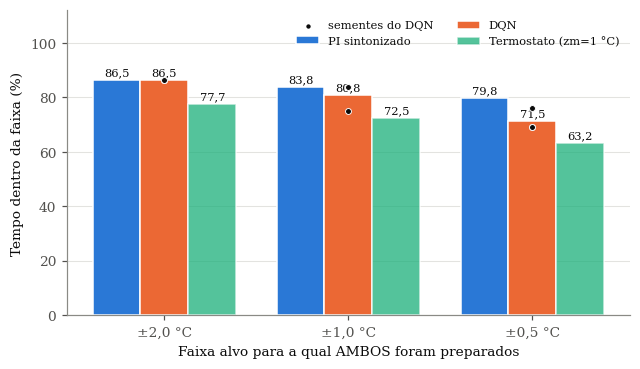

In [7]:
fig = F.fig_faixa_estreita(fx)
plt.close(fig)
fig

### Leitura — a hipótese é refutada, e o efeito é o inverso

| Faixa alvo | PI | DQN (3 sementes) | Vantagem do PI |
|---|---|---|---|
| ±2,0 °C | 86,5 % | 86,5 % | **+0,0 pp** |
| ±1,0 °C | 83,8 % | 80,8 % | **+3,0 pp** |
| ±0,5 °C | 79,8 % | 71,5 % | **+8,3 pp** |

Estreitar a faixa **amplia** a vantagem do controle clássico, monotonicamente —
o oposto da intuição. E há um segundo efeito: o desvio entre sementes do DQN
cresce de 0,00 para 5,20 e 4,04. Quando a especificação aperta, o treinamento não
só entrega menos, como fica **instável**.

## 4.5 "Mas treinou o suficiente?"

É a objeção óbvia, e nenhum experimento com orçamento fixo a responde. Seguindo
as Figs. 9-10 de Yuan et al. — que traçam custo e desconforto ano a ano —,
avaliamos o agente periodicamente **durante** o treino, contra a linha do PI.

O PI aparece como reta horizontal por construção: ele não aprende.

In [8]:
curva = R.curva_aprendizado()
curva.groupby(["tolerancia", "controlador", "passos"])["na_tolerancia_pct"].mean(
    ).unstack(level=0).tail(8).round(1)

tolerancia              0.5   2.0
controlador    passos            
DQN            250000  57.2  86.4
               275000  60.1  82.9
               300000  58.7  85.7
               325000  64.5  86.5
               350000  64.2  86.5
               375000  64.3  86.5
               400000  62.9  86.5
PI sintonizado 0       79.8  86.5

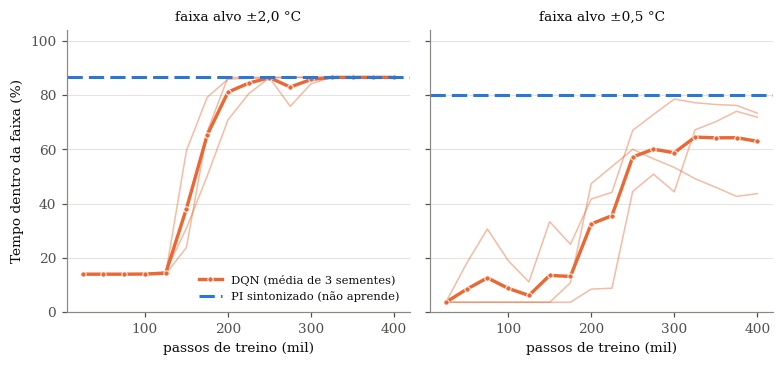

In [9]:
fig = F.fig_curva_aprendizado(curva)
plt.close(fig)
fig

### Leitura

Em **±2,0 °C** o DQN sai de 14 %, cruza rapidamente entre 100k e 250k passos e
**satura exatamente sobre a linha do PI** (86,5 % nas três sementes). O empate já
reportado não é coincidência de um ponto de parada: é o patamar de convergência.

Em **±0,5 °C** o quadro é outro. A curva sobe de 4 % para ~63 % e a 400k passos
está **16,9 pp abaixo** do PI. O crescimento desacelera muito — de 4 → 57 entre
25k e 250k, contra 57 → 63 nos 150k seguintes.

**Ressalva honesta:** a curva desacelera fortemente, mas **não é plana**. A
tendência nos últimos 150k passos ainda é de +2,9 pp. Mantida essa taxa — hipótese
otimista, que o próprio achatamento contradiz —, seriam necessários cerca de
**870k passos adicionais** para fechar a diferença. Portanto o que estes dados
sustentam não é "o DQN converge para pior", e sim que **o custo de amostra para
alcançar o PI é alto e cresce quando a faixa aperta**. A afirmação mais forte
exigiria um orçamento maior.

Note ainda a dispersão ao final: 73,3 / **43,7** / 71,8. Uma das três sementes
colapsa — a instabilidade da Seção 4.4 aparece aqui como trajetória, não só como
desvio-padrão.

O paralelo com Yuan et al. é direto: eles reportam o RL superando o PID apenas
após **dois anos de exploração mais dois anos de buffer**, com melhor desempenho
no sétimo ano. Alto custo de amostra neste domínio é um achado da literatura, não
uma particularidade desta implementação.

## 4.6 De onde vem a diferença de energia

As tabelas mostram que o DQN gasta ~4,7 % mais que o PI, mas não mostram **em
quê**. Seguindo a Fig. 11 de Yuan et al., que decompõe o consumo por item do
sistema, decompomos por **nível de potência acionado**.

In [10]:
from hvac.config import config_for_profile
cop = {k.name: v for k, v in config_for_profile("Equilibrado").physics.cop.items()}
dec = R.consumo_decomposto()
dec["por_nivel"].pivot(index="controlador", columns="nivel",
                       values="kwh_dia").round(2)

nivel,HIGH,LOW,MEDIUM,OFF
controlador,,,,
DQN Equilibrado,5.93,4.97,0.00,0.00
PI sintonizado,2.93,3.58,3.89,0.00
SAC Equilibrado,2.54,3.01,4.46,1.34
Termostato (zm = 0),1.17,0.00,6.38,0.00


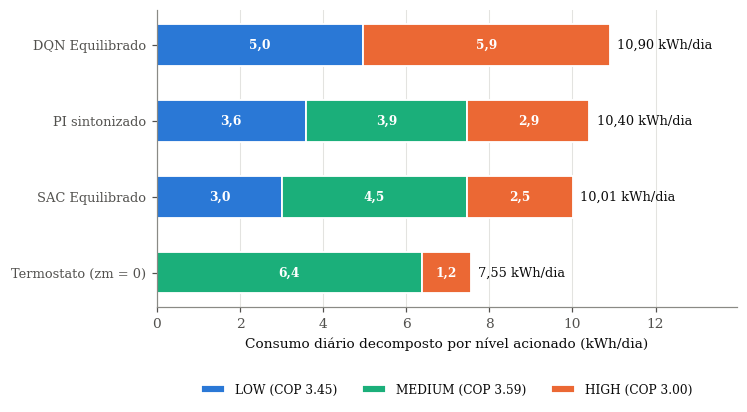

In [11]:
fig = F.fig_consumo_decomposto(dec, cop=cop)
plt.close(fig)
fig

### Leitura — o mecanismo do desperdício

| Controlador | OFF | LOW (COP 3,45) | MEDIUM (COP 3,59) | HIGH (COP 3,00) |
|---|---|---|---|---|
| PI | 55,4 % | 26,4 % | **13,5 %** | 4,7 % |
| DQN | 54,0 % | 36,6 % | **0,0 %** | 9,5 % |

**O DQN nunca usa MEDIUM** — precisamente o nível de maior COP do equipamento — e
compensa com o dobro de HIGH, o de pior COP. A energia extra não vem de operar
mais tempo; vem de operar nos níveis errados.

A causa é estrutural: uma política *greedy* determinística escolhe o argmax dos
Q-values. Uma ação que nunca seja o argmax **desaparece por completo** da
política, mesmo que seja quase ótima em muitos estados. Um controlador
proporcional, ao contrário, atravessa naturalmente todos os níveis ao percorrer a
faixa de erro.

Isso liga os dois achados: descartar o nível intermediário obriga a alternar
entre extremos, que é exatamente o *short-cycling* observado no painel de ações
da Seção 4.2.

## 4.7 Uma hipótese sobre a causa — testada e refutada

A degradação em faixa estreita sugeria uma explicação: PI e DQN compartilham o
mesmo espaço de ação, mas o PI tem **integrador**, e a observação do manuscrito é
puramente reativa (temperatura, ocupação, hora). Sem integrar o erro, não se
elimina offset — e com ±0,5 °C o offset passa a ser a diferença entre estar
dentro ou fora.

Hipótese testável: dar ao agente o erro escalado e o erro integral deveria
recuperar parte da distância.

In [12]:
ti = R.teste_integral()
ti.groupby(["variante", "n_canais"])["na_tolerancia_pct"].agg(
    ["mean", "std", "min", "max"]).round(2)

,,mean,std,min,max
variante,n_canais,,,,
+ erro escalado e integral,6,65.89,6.93,58.00,71.00
"obs do manuscrito (T, ocup., hora)",4,71.50,4.04,69.17,76.17


### Leitura — resultado negativo

| Observação | Na tolerância |
|---|---|
| Do manuscrito (4 canais) | **71,5 %** |
| + erro escalado e integral (6 canais) | **65,9 %** |

Acrescentar informação **piorou**. A hipótese não se sustenta: com o mesmo
orçamento de 300k passos, os canais extras ampliam o que há para aprender sem
compensar em desempenho.

Fica registrado como resultado negativo. A degradação do DQN em faixa estreita
tem mecanismo parcialmente explicado — o descarte do nível MEDIUM, Seção 4.6 —
mas a contribuição do estado insuficiente **não** foi demonstrada, e seria
desonesto apresentá-la como se tivesse sido.

## 4.8 Síntese

1. **Trajetórias.** O termostato estaciona acima da faixa; PI e DQN a mantêm. A
   diferença entre os dois não está na temperatura, está na **ação**: o PI modula,
   o DQN alterna entre extremos.
2. **Estreitar a faixa não favorece o RL** — favorece o PI, e de forma crescente:
   +0,0 → +3,0 → +8,3 pp. Com ambos preparados para cada largura.
3. **Não é simplesmente falta de treino.** Em ±2,0 °C o DQN converge sobre a
   linha do PI; em ±0,5 °C fica 16,9 pp abaixo com a curva já bastante achatada.
   O que se afirma é o custo de amostra elevado, não a impossibilidade — a
   distinção importa e está registrada na Seção 4.5.
4. **A energia extra tem mecanismo identificado**: a política aprendida descarta o
   nível de melhor eficiência do equipamento.
5. **Uma hipótese explicativa foi testada e refutada** — dar estado suficiente ao
   agente não recuperou o desempenho.

O conjunto reforça a conclusão dos notebooks anteriores, agora com mecanismo: em
rastreamento de setpoint com modelo conhecido, o controle clássico não é apenas
competitivo — ele é estruturalmente mais adequado, e a vantagem **cresce** com a
exigência de precisão.